In [1]:
!pip install gensim
!pip install google-generativeai -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 25.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import nltk

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

import numpy as np
import seaborn as sns
from gensim.models import Word2Vec, KeyedVectors
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import gensim.downloader as api
from gensim.models import Word2Vec


In [3]:
from datasets import load_dataset
dataset = load_dataset("tuetschek/atis")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


atis_train.csv: 0.00B [00:00, ?B/s]

atis_test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/4978 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/893 [00:00<?, ? examples/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'intent', 'text', 'slots'],
        num_rows: 4978
    })
    test: Dataset({
        features: ['id', 'intent', 'text', 'slots'],
        num_rows: 893
    })
})

Data Exploration

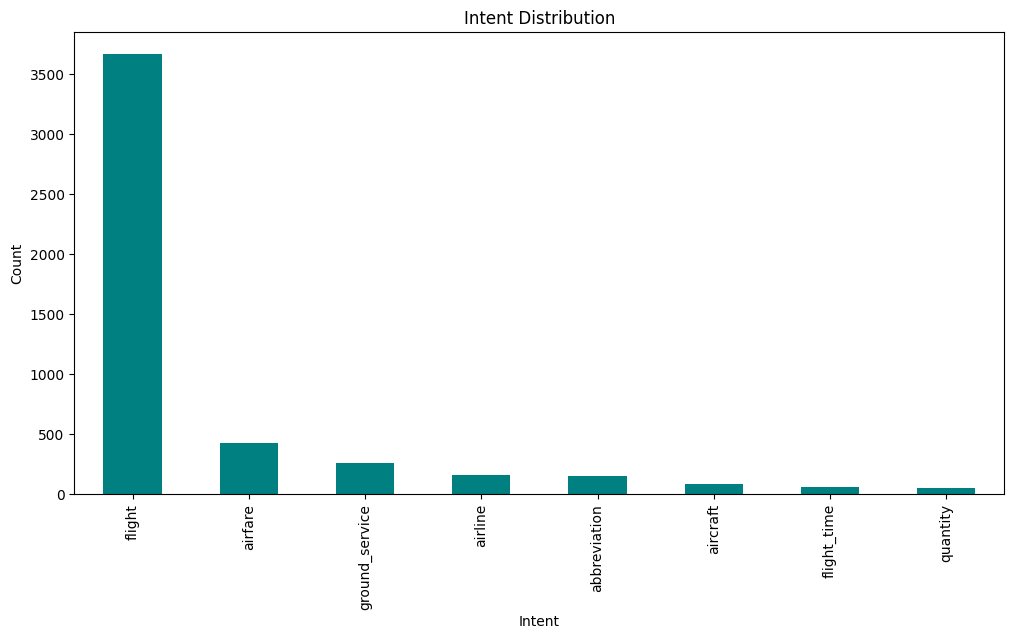

In [17]:
#Intent Distribution
df = dataset['train'].to_pandas()
intent_counts = df['intent'].value_counts()

plt.figure(figsize=(12,6))
intent_counts.plot(kind='bar', color='teal')
plt.title("Intent Distribution")
plt.xlabel("Intent")
plt.ylabel("Count")
plt.show()


In [4]:
# removing rare intents
selected_intents = [

    "flight",
    "airfare",
    "ground_service",
    "airline",
    "abbreviation",
    "aircraft",
    "flight_time",
    "quantity"
]

dataset = dataset.filter(lambda example: example['intent'] in selected_intents)

Filter:   0%|          | 0/4978 [00:00<?, ? examples/s]

Filter:   0%|          | 0/893 [00:00<?, ? examples/s]

In [ ]:
df_train = dataset['train'].to_pandas()
df_train.head()



,id,intent,text,slots
0,0,flight,i want to fly from boston at 838 am and arrive...,O O O O O B-fromloc.city_name O B-depart_time....
1,1,flight,what flights are available from pittsburgh to ...,O O O O O B-fromloc.city_name O B-toloc.city_n...
2,2,flight_time,what is the arrival time in san francisco for ...,O O O B-flight_time I-flight_time O B-fromloc....
3,3,airfare,cheapest airfare from tacoma to orlando,B-cost_relative O O B-fromloc.city_name O B-to...
4,4,airfare,round trip fares from pittsburgh to philadelph...,B-round_trip I-round_trip O O B-fromloc.city_n...


In [ ]:
df_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4834 entries, 0 to 4833
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      4834 non-null   int64 
 1   intent  4834 non-null   object
 2   text    4834 non-null   object
 3   slots   4834 non-null   object
dtypes: int64(1), object(3)
memory usage: 151.2+ KB


In [ ]:
df_train.describe(include='all')

,id,intent,text,slots
count,4834.00000,4834,4834,4834
unique,NaN,8,4499,2812
top,NaN,flight,what is fare code h,O O O O O B-fromloc.city_name O B-toloc.city_name
freq,NaN,3666,8,195
mean,2482.86657,NaN,NaN,NaN
std,1436.09454,NaN,NaN,NaN
min,0.00000,NaN,NaN,NaN
25%,1240.25000,NaN,NaN,NaN
50%,2479.50000,NaN,NaN,NaN
75%,3723.75000,NaN,NaN,NaN


In [ ]:
df_train['intent'].nunique()


8

In [ ]:
df_train['text'].isnull().sum()

np.int64(0)

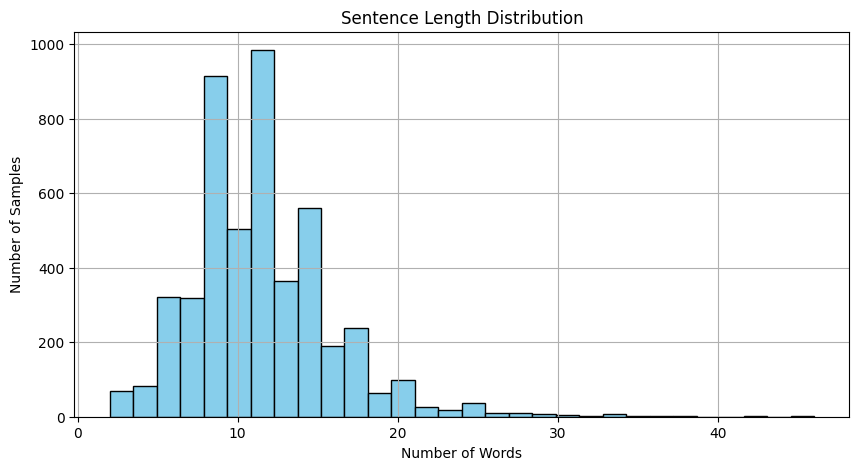

In [ ]:
#Sentence Length Analysis
df_train['sentence_length'] = df_train['text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10,5))
df_train['sentence_length'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title("Sentence Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Samples")
plt.show()

In [ ]:
#Word Frequency (Before Cleaning)

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
all_words = []
for text in df_train['text']:
    all_words.extend(nltk.word_tokenize(text.lower()))

word_freq = Counter(all_words).most_common(20)
word_freq


[('to', 4244),
 ('from', 3655),
 ('flights', 2406),
 ('the', 2006),
 ('on', 1472),
 ('what', 1294),
 ('me', 1238),
 ('flight', 1148),
 ('boston', 1057),
 ('show', 1039),
 ('san', 988),
 ('i', 986),
 ('denver', 979),
 ('a', 873),
 ('francisco', 852),
 ('in', 828),
 ('and', 747),
 ('atlanta', 740),
 ('pittsburgh', 671),
 ('dallas', 634)]

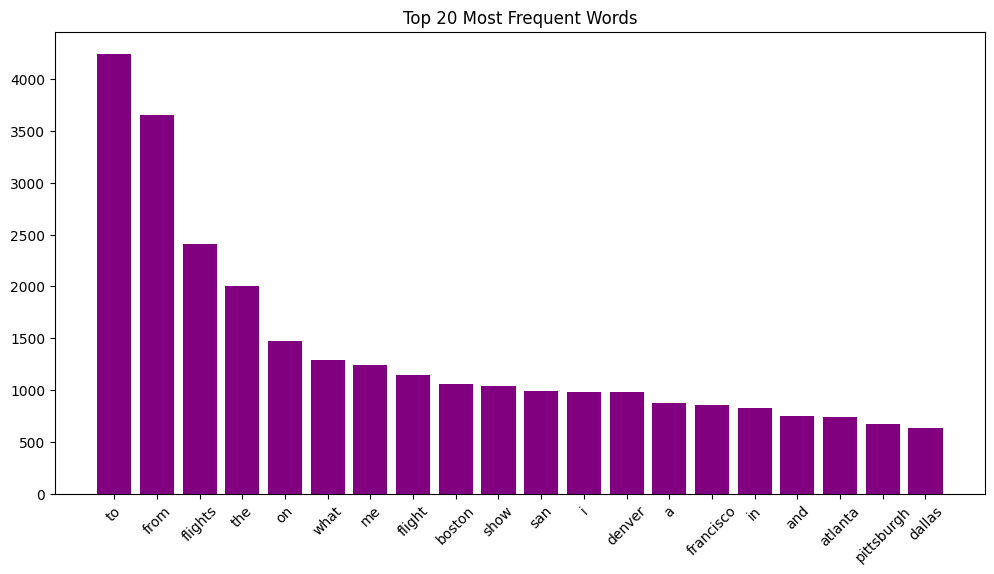

In [ ]:
#Visualize Top Words
words, counts = zip(*word_freq)

plt.figure(figsize=(12,6))
plt.bar(words, counts, color='purple')
plt.title("Top 20 Most Frequent Words")
plt.xticks(rotation=45)
plt.show()

In [ ]:

#Intent vs Sentence Length
df_train.groupby('intent')['sentence_length'].mean().sort_values()

,sentence_length
intent,
abbreviation,5.217687
ground_service,8.584314
airline,9.025478
quantity,10.862745
flight,11.750682
airfare,12.340426
flight_time,13.148148
aircraft,14.271605


Cleaning(Lowercase+ Remove Punctuation)

In [5]:
import string
from nltk.corpus import stopwords
nltk.download("stopwords", quiet=True)

def clean_my_data(example, remove_stopwords=False):
    lowered = example['text'].lower()
    cleaned = lowered.translate(str.maketrans('', '', string.punctuation))

    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
        tokens = cleaned.split()
        cleaned = ' '.join([word for word in tokens if word not in stop_words])

    return {'cleaned_text': cleaned}



In [6]:
dataset = dataset.map(clean_my_data)


Map:   0%|          | 0/4834 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Word Tokenization

In [7]:
from nltk.tokenize import word_tokenize

nltk.download("punkt",quiet=True)
nltk.download("punkt_tab",quiet=True)
def tokenize_words(example):
  example["tokens"] = word_tokenize(example["cleaned_text"])
  return example

dataset_tokenized = dataset.map(tokenize_words)

Map:   0%|          | 0/4834 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

In [ ]:
print(dataset_tokenized['train'][0]['tokens'])

['i', 'want', 'to', 'fly', 'from', 'boston', 'at', '838', 'am', 'and', 'arrive', 'in', 'denver', 'at', '1110', 'in', 'the', 'morning']


In [ ]:
#Train and Test Size --> num of samples
print(f"Train Size: {len(dataset_tokenized['train'])}")
print(f"Test Size: {len(dataset_tokenized['test'])}")

Train Size: 4834
Test Size: 800


In [ ]:
all_tokens = []

for tokens in list(dataset_tokenized['train']['tokens']) + list(dataset_tokenized['test']['tokens']):
  for token in  tokens:
    all_tokens.append(token)

#Total number of tokens --> num of individual words(with duplicates)
print(f"Total number of tokens: {len(all_tokens)}")

#Total number of unique tokens --> num of unique words in data
print(f"Total number of unique tokens:  {len(set(all_tokens))}")

Total number of tokens: 63400
Total number of unique tokens:  902


In [ ]:
#Number of tokens per class
intents_train = list(dataset_tokenized['train']['intent'])
tokens_train = list(dataset_tokenized['train']['tokens'])

intents_test = list(dataset_tokenized['test']['intent'])
tokens_test = list(dataset_tokenized['test']['tokens'])

all_intents = intents_train + intents_test
all_tokens = tokens_train + tokens_test

tokens_per_class = {}

for intent, token in zip (all_intents, all_tokens):
  if intent not in tokens_per_class:
    tokens_per_class[intent] = 0 #if intent hasn't been seen before -> add to dictionary with initial count of 0
  tokens_per_class[intent] += len(tokens) #accumalate token count in each class/intent

for intent, count in sorted(tokens_per_class.items()):
  print(f"{intent}: {count} tokens")

abbreviation: 1800 tokens
aircraft: 900 tokens
airfare: 4710 tokens
airline: 1950 tokens
flight: 42980 tokens
flight_time: 550 tokens
ground_service: 2910 tokens
quantity: 540 tokens


## Traditional Approach Baselines

Two baseline models are used for intent classification:

1. **TF-IDF + Random Forest**
2. **Word2Vec + Logistic Regression**

## TF-IDF + Random Forest

In [9]:
rf_clsfr = Pipeline([
    ('vectorizer_tfidf', TfidfVectorizer()),
    ('Random_Forest', RandomForestClassifier(random_state=42))
])

rf_clsfr.fit(dataset_tokenized['train']['cleaned_text'], dataset_tokenized['train']['intent'])
y_pred_rf = rf_clsfr.predict(dataset_tokenized['test']['cleaned_text'])

print(classification_report(dataset_tokenized['test']['intent'], y_pred_rf))

                precision    recall  f1-score   support

  abbreviation       1.00      1.00      1.00        33
      aircraft       0.82      1.00      0.90         9
       airfare       0.92      0.94      0.93        48
       airline       1.00      0.76      0.87        38
        flight       0.98      0.98      0.98       632
   flight_time       1.00      1.00      1.00         1
ground_service       1.00      1.00      1.00        36
      quantity       0.43      1.00      0.60         3

      accuracy                           0.97       800
     macro avg       0.89      0.96      0.91       800
  weighted avg       0.98      0.97      0.97       800



In [ ]:
x_test_samples = dataset_tokenized['test']['cleaned_text'][:5]
y_test_samples = dataset_tokenized['test']['intent'][:5]
#get predictions for same samples
y_pred_samples = y_pred_rf[:5]


#print next to eachother
print(f"{'Actual Text':<50} | {'True':<10} | {'Predicted'}")
print("-" * 80)
for text, true, pred in zip(x_test_samples, y_test_samples, y_pred_samples):
    print(f"{text[:45]:<50} | {true:<10} | {pred}")

Actual Text                                        | True       | Predicted
--------------------------------------------------------------------------------
i would like to find a flight from charlotte       | flight     | flight
on april first i need a ticket from tacoma to      | airfare    | airfare
on april first i need a flight going from pho      | flight     | flight
i would like a flight traveling one way from       | flight     | flight
i would like a flight from orlando to salt la      | flight     | flight


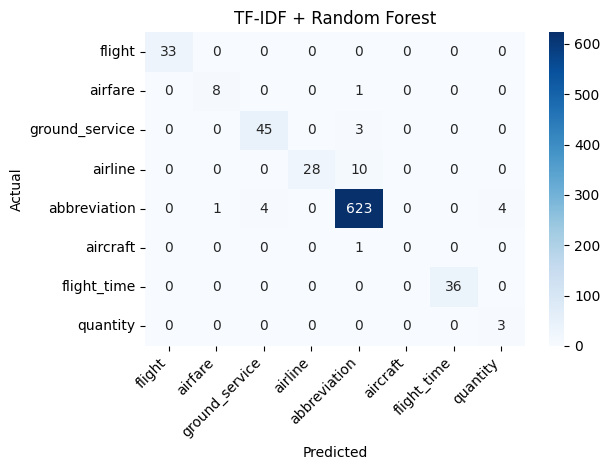

In [ ]:
sns.heatmap(confusion_matrix(dataset_tokenized['test']['intent'], y_pred_rf),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=selected_intents,
            yticklabels=selected_intents)
plt.title("TF-IDF + Random Forest")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Word2Vec + Logistic Regression

In [15]:
df_train = dataset_tokenized['train'].to_pandas()[['cleaned_text', 'intent', 'tokens']]
df_test  = dataset_tokenized['test'].to_pandas()[['cleaned_text', 'intent', 'tokens']]

In [16]:

#downloading pretrained Word2Vec vec
w2v_model = api.load("word2vec-google-news-300")
print(" Vocabulary size:", len(w2v_model))

[==================================================] 100.0% 1662.8/1662.8MB downloaded
 Vocabulary size: 3000000


In [19]:
# Train w2v on ATIS training sentences
from gensim.models import Word2Vec

# custom wrd2vec
custom_w2v = Word2Vec(
    sentences=[list(tokens) for tokens in df_train['tokens']],
    vector_size=300

)

custom_w2v_wv = custom_w2v.wv

print("Custom vocabulary size:", len(custom_w2v_wv))

Custom vocabulary size: 422


In [20]:
train_texts_joined = [' '.join(tokens) for tokens in df_train['tokens']]
test_texts_joined  = [' '.join(tokens) for tokens in df_test['tokens']]

tfidf = TfidfVectorizer()
tfidf.fit(train_texts_joined)
tfidf_weights = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))

print(f"TF-IDF vocabulary size: {len(tfidf_weights)}")

TF-IDF vocabulary size: 837


In [21]:
def tfidf_weighted_mean(tokens, model, weights):
    vectors = []
    word_weights = []

    for word in tokens:
        if word in model and word in weights:
            vectors.append(model[word])
            word_weights.append(weights[word])


    if len(vectors) == 0:
        return np.zeros(300)


    vectors = np.array(vectors)
    word_weights = np.array(word_weights)

    return np.average(vectors, axis=0, weights=word_weights)

In [22]:

# encode vectors using TF-IDF Weighted Mean
X_train_pretrained = np.array([tfidf_weighted_mean(tokens, w2v_model, tfidf_weights)
                           for tokens in df_train['tokens']])
X_test_pretrained  = np.array([tfidf_weighted_mean(tokens, w2v_model, tfidf_weights)
                           for tokens in df_test['tokens']])

print(f"train shape using pretrained W2V: {X_train_pretrained.shape}, Test shape: {X_test_pretrained.shape}")

X_train_custom = np.array([tfidf_weighted_mean(tokens, custom_w2v.wv, tfidf_weights)
                           for tokens in df_train['tokens']])
X_test_custom  = np.array([tfidf_weighted_mean(tokens, custom_w2v.wv, tfidf_weights)
                           for tokens in df_test['tokens']])

print(f"train shape using custom W2V: {X_train_custom.shape}, Test shape: {X_test_custom.shape}")

y_train = df_train['intent']
y_test  = df_test['intent']

train shape using pretrained W2V: (4834, 300), Test shape: (800, 300)
train shape using custom W2V: (4834, 300), Test shape: (800, 300)


In [25]:
clf_custom = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
clf_custom.fit(X_train_custom, y_train)
print("Custom Word2Vec + TF-IDF")
y_pred_custom = clf_custom.predict(X_test_custom)
print(classification_report(y_test, clf_custom.predict(X_test_custom)))

Custom Word2Vec + TF-IDF
                precision    recall  f1-score   support

  abbreviation       0.57      0.61      0.59        33
      aircraft       0.00      0.00      0.00         9
       airfare       0.31      0.25      0.28        48
       airline       0.00      0.00      0.00        38
        flight       0.89      0.98      0.93       632
   flight_time       0.00      0.00      0.00         1
ground_service       1.00      0.83      0.91        36
      quantity       0.00      0.00      0.00         3

      accuracy                           0.85       800
     macro avg       0.35      0.33      0.34       800
  weighted avg       0.79      0.85      0.82       800



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


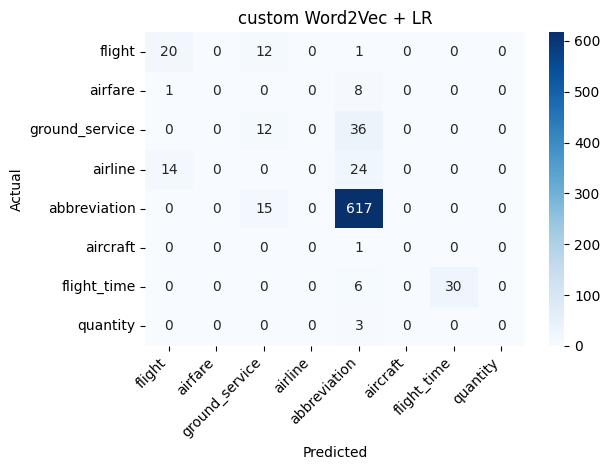

In [27]:
sns.heatmap(confusion_matrix(y_test, y_pred_custom),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=selected_intents,
            yticklabels=selected_intents)
plt.title("custom Word2Vec + LR")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [28]:
clf_pretrainedW2V = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
clf_pretrainedW2V.fit(X_train_pretrained, y_train)
y_pred_pretrained = clf_pretrainedW2V.predict(X_test_pretrained)
print("Pretrained Word2Vec + TF-IDF")

print(classification_report(y_test, clf_pretrainedW2V.predict(X_test_pretrained)))

Pretrained Word2Vec + TF-IDF
                precision    recall  f1-score   support

  abbreviation       1.00      1.00      1.00        33
      aircraft       0.75      1.00      0.86         9
       airfare       0.92      0.92      0.92        48
       airline       0.97      0.76      0.85        38
        flight       0.98      0.99      0.98       632
   flight_time       1.00      1.00      1.00         1
ground_service       1.00      0.97      0.99        36
      quantity       0.33      0.33      0.33         3

      accuracy                           0.97       800
     macro avg       0.87      0.87      0.87       800
  weighted avg       0.97      0.97      0.97       800



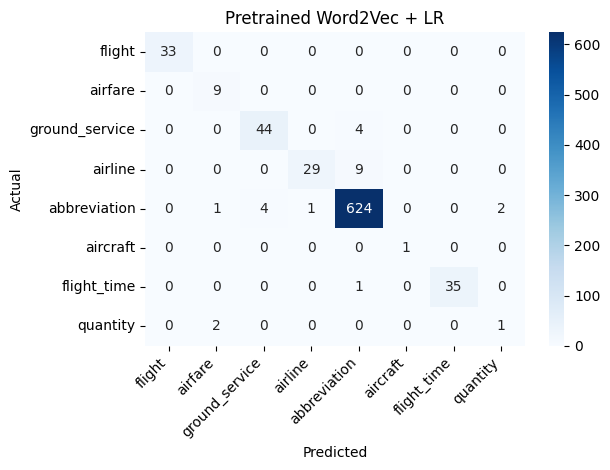

In [29]:
sns.heatmap(confusion_matrix(y_test, y_pred_pretrained),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=selected_intents,
            yticklabels=selected_intents)
plt.title("Pretrained Word2Vec + LR")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## LLM-based Approach: Prompt-based Intent Classification

In [ ]:
from google.colab import userdata
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
import google.generativeai as genai

genai.configure(api_key=GEMINI_API_KEY)

model = genai.GenerativeModel("gemini-2.5-flash")
print("Gemini ready")

TimeoutException: Requesting secret GEMINI_API_KEY timed out. Secrets can only be fetched when running from the Colab UI.

In [ ]:
few_shot_examples = """
Sentence: "show me flights from boston to new york" → flight
Sentence: "how much does it cost to fly to dallas" → airfare
Sentence: "how do i get from the airport to downtown" → ground_service
Sentence: "which airlines fly to chicago" → airline
Sentence: "what does ua stand for" → abbreviation
Sentence: "what kind of plane is used on this route" → aircraft
Sentence: "what time does the flight arrive" → flight_time
Sentence: "how many flights go to seattle daily" → quantity
"""

In [ ]:
def classify_intent_gemini(text):
    prompt = f"""You are an intent classification system for an airline query system.

Classify the sentence into exactly ONE of these intents:
flight, airfare, ground_service, airline, abbreviation, aircraft, flight_time, quantity

Examples:
{few_shot_examples}

Now classify this:
Sentence: "{text}"

Reply with only the intent label, nothing else."""

    response = model.generate_content(prompt)
    predicted = response.text.strip().lower()


    valid_intents = ['flight', 'airfare', 'ground_service', 'airline',
                     'abbreviation', 'aircraft', 'flight_time', 'quantity']
    if predicted not in valid_intents:
        predicted = "unknown"

    return predicted

In [ ]:
import time
gemini_predictions = []

df_test_gemini=dataset['test'].to_pandas()


for i, text in enumerate(df_test['cleaned_text']):
    pred = classify_intent_gemini(text)
    gemini_predictions.append(pred)
    print(f"Processed {i + 1}/{len(df_test)} | Predicted: {pred}")



    time.sleep(2)

In [ ]:
#storing gemeni predictions in DF

results_df = pd.DataFrame({
    'text': df_test['cleaned_text'],
    'true_intent': df_test['intent'],
    'predicted_intent': gemini_predictions
})

results_df.to_csv('gemini_predictions.csv', index=False)


In [10]:
results_df = pd.read_csv('gemini_predictions.csv') # getting gemini predictions
print(results_df.shape)
results_df.head()

(800, 3)


,text,true_intent,predicted_intent
0,i would like to find a flight from charlotte t...,flight,flight
1,on april first i need a ticket from tacoma to ...,airfare,flight
2,on april first i need a flight going from phoe...,flight,flight
3,i would like a flight traveling one way from p...,flight,flight
4,i would like a flight from orlando to salt lak...,flight,flight


In [11]:
y_true = results_df['true_intent']
y_Gemini_pred = results_df['predicted_intent']

In [12]:
print(classification_report(y_true, y_Gemini_pred))

                precision    recall  f1-score   support

  abbreviation       0.68      0.85      0.76        33
      aircraft       0.89      0.89      0.89         9
       airfare       0.76      0.92      0.83        48
       airline       1.00      0.66      0.79        38
        flight       0.99      0.96      0.98       632
   flight_time       0.09      1.00      0.17         1
ground_service       1.00      1.00      1.00        36
      quantity       0.38      1.00      0.55         3

      accuracy                           0.94       800
     macro avg       0.72      0.91      0.74       800
  weighted avg       0.96      0.94      0.95       800



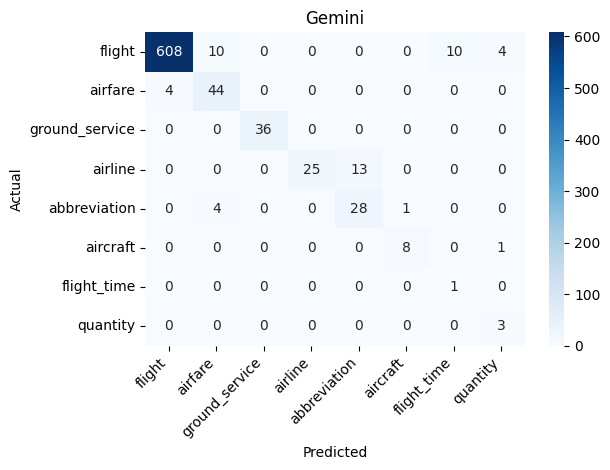

In [30]:
sns.heatmap(confusion_matrix(y_true, y_Gemini_pred, labels=selected_intents),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=selected_intents,
            yticklabels=selected_intents)
plt.title("Gemini")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Traditional Approach VS LLM-based Approach

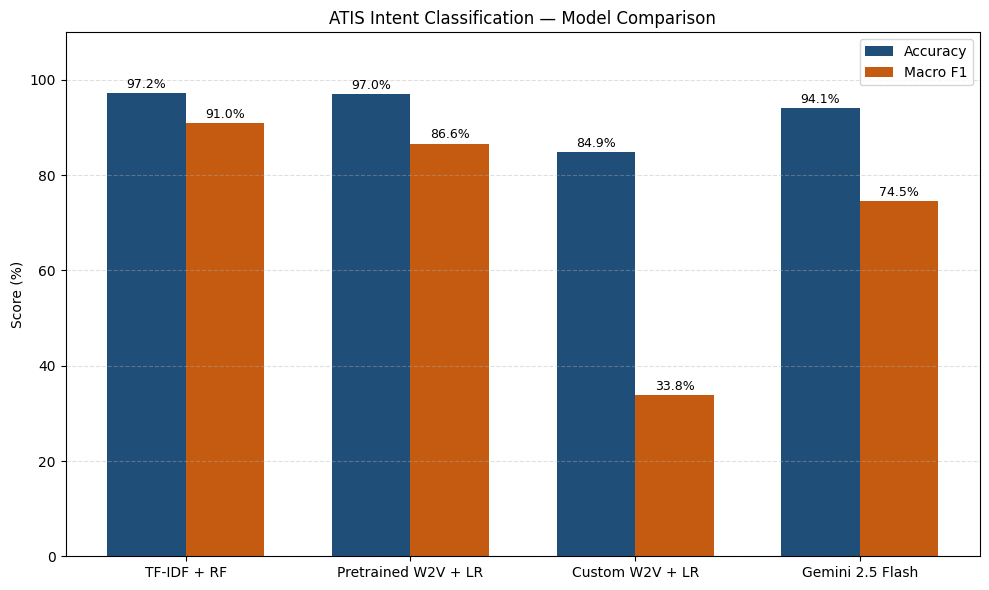

In [31]:
models = ["TF-IDF + RF", "Pretrained W2V + LR", "Custom W2V + LR", "Gemini 2.5 Flash"]

accuracy = [
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_pretrained),
    accuracy_score(y_test, y_pred_custom),
    accuracy_score(y_true, y_Gemini_pred),
]

macro_f1 = [
    f1_score(y_test, y_pred_rf,            average="macro"),
    f1_score(y_test, y_pred_pretrained, average="macro"),
    f1_score(y_test, y_pred_custom,     average="macro"),
    f1_score(y_true, y_Gemini_pred,     average="macro"),
]


accuracy = [v * 100 for v in accuracy]
macro_f1 = [v * 100 for v in macro_f1]


x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, accuracy, width, label="Accuracy", color="#1f4e79")
bars2 = ax.bar(x + width/2, macro_f1, width, label="Macro F1", color="#c55a11")

# Value labels
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Score (%)")
ax.set_title("ATIS Intent Classification — Model Comparison")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 110)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("baseline_comparison.png", dpi=150)
plt.show()